📌 TensorFlow with Built-in Layers

✅ A 3-layer deep neural network (input → hidden1 → hidden2 → output)

✅ Uses TensorFlow einsum instead of standard matrix multiplication

✅ Uses TensorFlow's Built-in API (tf.keras.layers)

✅ Uses tf.keras.Model with Keras' built-in layers (Dense, ReLU, Adam, etc.)

✅ Uses a 3-variable-based non-linear equation for synthetic data generation

✅ Plots 4D visualization of generated data before training

✅ Includes training loss curve, actual vs predicted values, and 4D scatter plot of predictions

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Generate Synthetic Data

In [2]:
def generate_data(n_samples=1000):
    X1 = np.random.uniform(-5, 5, n_samples)
    X2 = np.random.uniform(-5, 5, n_samples)
    X3 = np.random.uniform(-5, 5, n_samples)

    # Complex non-linear equation with 3 variables
    y = (2 * np.sin(X1) + 0.5 * X2**2 + 0.3 * X3**3 +
         np.cos(X1 * X2) + np.random.normal(0, 0.2, n_samples))

    X = np.column_stack((X1, X2, X3))
    return X.astype(np.float32), y.reshape(-1, 1).astype(np.float32)

# Generate data
X, y = generate_data(1000)

# Step 2: Plot Synthetic Data

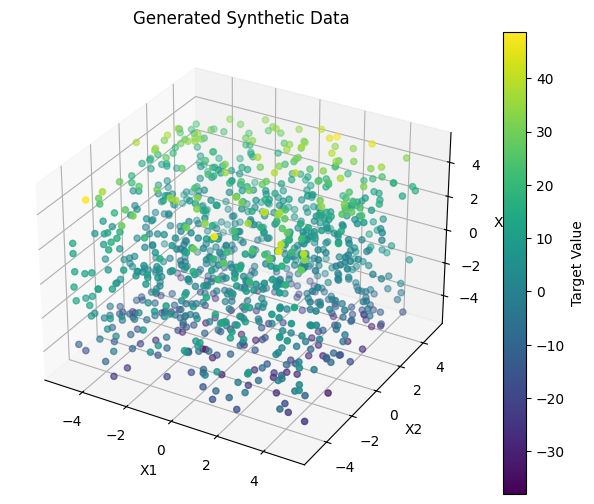

In [3]:
def plot_synthetic_data(X, y):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y[:, 0], cmap='viridis')
    plt.colorbar(scatter, label='Target Value')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('Generated Synthetic Data')
    plt.show()

plot_synthetic_data(X, y)

In [4]:
# Convert data into TensorFlow tensors
X_train = tf.convert_to_tensor(X, dtype=tf.float32)
y_train = tf.convert_to_tensor(y, dtype=tf.float32)

# Step 3: Define Neural Network using Built-in Layers

In [5]:
class BuiltInNN(tf.keras.Model):
    def __init__(self):
        super(BuiltInNN, self).__init__()
        self.dense1 = tf.keras.layers.Dense(64, activation='relu')
        self.dense2 = tf.keras.layers.Dense(32, activation='relu')
        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        return self.output_layer(x)

In [6]:
# Create the model
model = BuiltInNN()


In [7]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='mse')

# Step 4: Train the Model

In [8]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 205.6860
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 143.2856
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 80.8309
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 48.9486
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 44.5257
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41.7003
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39.5210
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36.1743
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35.7802
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 33.8633
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33.5302
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32.0472
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 29.9463
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 32.0509
Epoch 15/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - l

# Step 5: Plot Training Loss

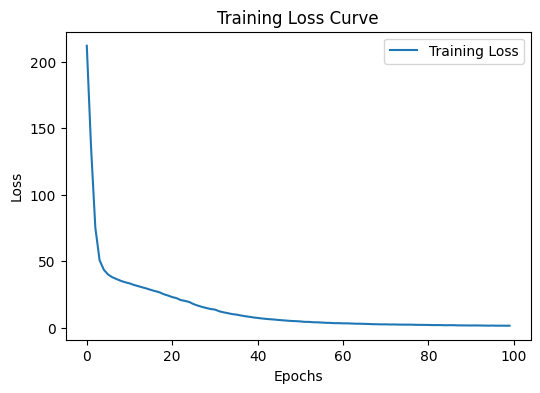

In [9]:
def plot_training_loss(history):
    plt.figure(figsize=(6, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.legend()
    plt.show()

plot_training_loss(history)

# Step 6: Generate Predictions

In [10]:
y_pred = model.predict(X_train)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


# Step 7: Plot 4D Scatter of Predictions

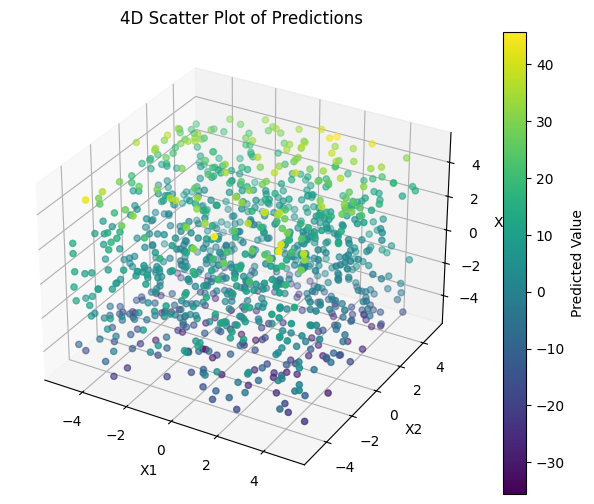

In [11]:
def plot_4d_scatter(X, y_pred):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_pred[:, 0], cmap='viridis')
    plt.colorbar(scatter, label='Predicted Value')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('4D Scatter Plot of Predictions')
    plt.show()

plot_4d_scatter(X, y_pred)

# Step 8: Plot Actual vs Predicted Values

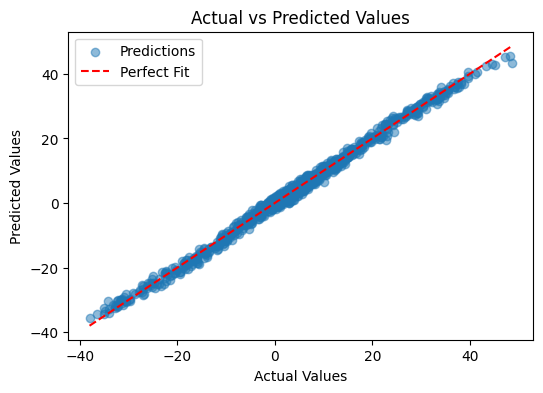

In [12]:
def plot_actual_vs_predicted(y, y_pred):
    plt.figure(figsize=(6, 4))
    plt.scatter(y, y_pred, alpha=0.5, label="Predictions")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label="Perfect Fit")
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.legend()
    plt.show()

plot_actual_vs_predicted(y, y_pred)

# Step 9: Test Model on New Data Points

In [13]:
def test_model(model, x1, x2, x3):
    x_tensor = tf.convert_to_tensor([[x1, x2, x3]], dtype=tf.float32)
    prediction = model(x_tensor)
    return prediction.numpy()[0, 0]

# Define test points
test_points = [(-4, -4, -4), (-2, -2, -2), (0, 0, 0), (2, 2, 2), (4, 4, 4)]

print("\nTest Predictions:")
for x1, x2, x3 in test_points:
    pred = test_model(model, x1, x2, x3)
    actual = 2 * np.sin(x1) + 0.5 * x2**2 + 0.3 * x3**3 + np.cos(x1 * x2)
    print(f"Input: ({x1}, {x2}, {x3})")
    print(f"Prediction: {pred:.3f}")
    print(f"Actual: {actual:.3f}\n")


Test Predictions:
Input: (-4, -4, -4)
Prediction: -10.952
Actual: -10.644

Input: (-2, -2, -2)
Prediction: -0.287
Actual: -2.872

Input: (0, 0, 0)
Prediction: -1.308
Actual: 1.000

Input: (2, 2, 2)
Prediction: 5.699
Actual: 5.565

Input: (4, 4, 4)
Prediction: 25.708
Actual: 24.729

